# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 10_GSE296969_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/10_GSE296969.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
sc.settings.verbosity = 1
print(sc.__version__)

1.9.6


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 读取数据
GSE296969数据集：
- 结肠组织 基质细胞
- 7UC，6HC

In [5]:
adata = sc.read_h5ad('/Users/future/Nutstore Files/UC/scRNA-seq_data/02_sample_merge/10_GSE296969.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 105648 × 27980
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [7]:
adata.obs.head()

,n_genes,GSM_id,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
GSM8980878_UC68_CELL2_N3,5579,GSM8980878_UC68,GSM8980878,UC68,16160.0,0.049505,5579,0.345235,True,True,True,0.047338,False
GSM8980878_UC68_CELL6_N4,790,GSM8980878_UC68,GSM8980878,UC68,1128.0,0.079787,790,0.700355,True,True,True,0.024741,False
GSM8980878_UC68_CELL10_N2,1807,GSM8980878_UC68,GSM8980878,UC68,3051.0,0.077352,1807,0.592265,True,True,True,0.025539,False
GSM8980878_UC68_CELL14_N2,3154,GSM8980878_UC68,GSM8980878,UC68,6273.0,0.039694,3154,0.502790,True,True,True,0.011227,False
GSM8980878_UC68_CELL16_N2,1762,GSM8980878_UC68,GSM8980878,UC68,3086.0,0.126701,1762,0.570966,True,True,True,0.023966,False


## 处理细胞标签及分组

In [8]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                             id group
GSM8980878_UC68_CELL2_N3   UC68    UC
GSM8980878_UC68_CELL6_N4   UC68    UC
GSM8980878_UC68_CELL10_N2  UC68    UC
GSM8980878_UC68_CELL14_N2  UC68    UC
GSM8980878_UC68_CELL16_N2  UC68    UC


`.obs`当中只保留GSM信息和分组信息

In [9]:
adata.obs.drop(columns=['GSM_id', 'id'], inplace=True)
print(adata.obs.head())

                           n_genes         GSM    nUMIs  mito_perc  \
GSM8980878_UC68_CELL2_N3      5579  GSM8980878  16160.0   0.049505   
GSM8980878_UC68_CELL6_N4       790  GSM8980878   1128.0   0.079787   
GSM8980878_UC68_CELL10_N2     1807  GSM8980878   3051.0   0.077352   
GSM8980878_UC68_CELL14_N2     3154  GSM8980878   6273.0   0.039694   
GSM8980878_UC68_CELL16_N2     1762  GSM8980878   3086.0   0.126701   

                           detected_genes  cell_complexity  passing_mt  \
GSM8980878_UC68_CELL2_N3             5579         0.345235        True   
GSM8980878_UC68_CELL6_N4              790         0.700355        True   
GSM8980878_UC68_CELL10_N2            1807         0.592265        True   
GSM8980878_UC68_CELL14_N2            3154         0.502790        True   
GSM8980878_UC68_CELL16_N2            1762         0.570966        True   

                           passing_nUMIs  passing_ngenes  doublet_score  \
GSM8980878_UC68_CELL2_N3            True            True   

In [10]:
adata.obs['group'].value_counts()

group
UC    54683
HC    50965
Name: count, dtype: int64

## 样本质量查看

In [11]:
adata.obs['GSM'].value_counts()

GSM
GSM8980880    11289
GSM8980882    10199
GSM8980878    10169
GSM8980887     9875
GSM8980885     8991
GSM8980886     8972
GSM8980889     7945
GSM8980881     7179
GSM8980879     7030
GSM8980888     6738
GSM8980884     6373
GSM8980883     5455
GSM8980890     5433
Name: count, dtype: int64

In [12]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                                 nUMIs               \
                   mean          std  min    max         mean          std   
GSM                                                                          
GSM8980878  2224.985643  1034.823430  252  11376  4752.102051  3400.139404   
GSM8980879   791.703272   402.056472  294   6192  1231.089478   852.503357   
GSM8980880  2025.669767   843.296659  347   8324  4156.070312  2616.517090   
GSM8980881  2620.324836  1117.982061  367   9668  6556.607910  4448.737305   
GSM8980882  1998.027748   923.297999  279   8164  4247.822754  2888.941162   
GSM8980883  2699.804583  1246.336666  473   9197  7412.815430  5642.575195   
GSM8980884  2537.796642  1294.184522  546  10853  5436.023438  4074.900635   
GSM8980885  1532.297186   717.899185  260   7347  2911.377686  1966.064331   
GSM8980886  2270.286001  1004.458832  272  10346  5054.012207  3464.619141   
GSM8980887  2136.689722   975.790459  259   9209  5026.074707  3

/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_44358/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

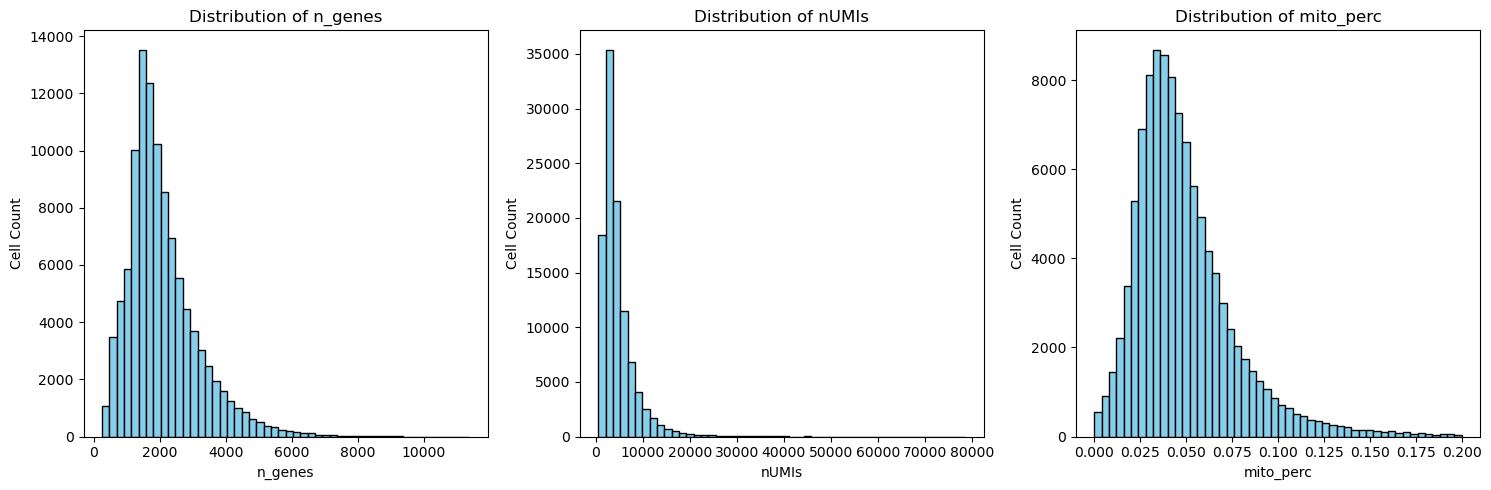

In [13]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_44358/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

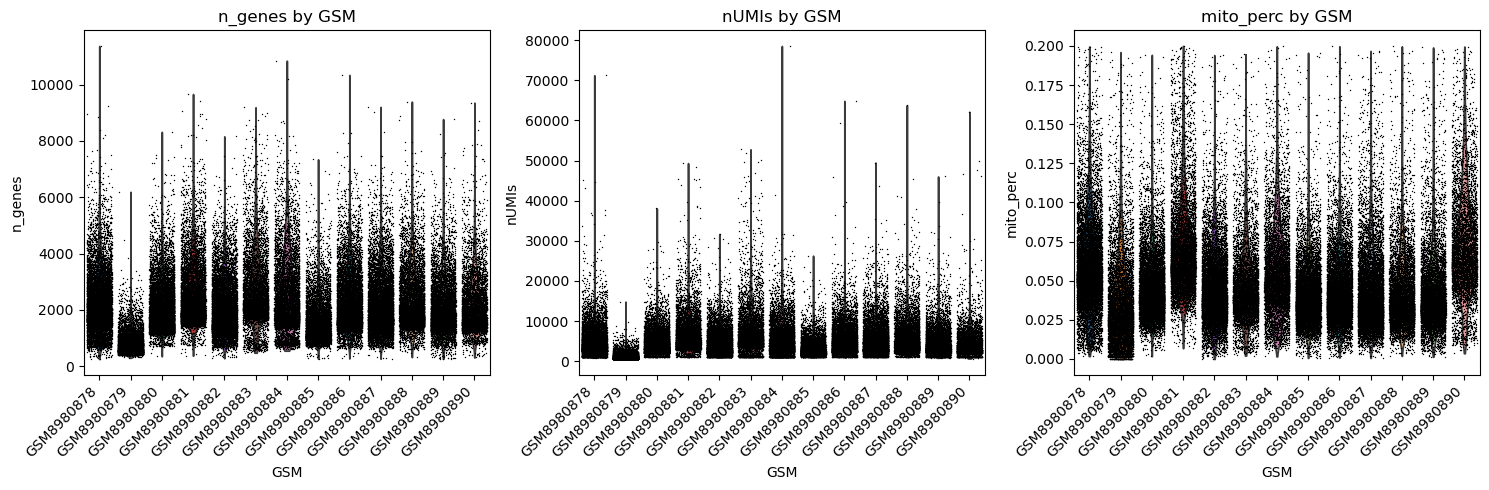

In [14]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 5000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [15]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 5000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 98112


## 保存质控后数据


In [16]:
import os
output_dir = "/Users/future/Nutstore Files/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "10_GSE296969_qc.h5ad"), compression='gzip')

## 降维聚类

In [ ]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

血液组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [ ]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [ ]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## GPT自动注释

In [ ]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

In [ ]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

In [ ]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

In [ ]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [ ]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)